In [18]:
import numpy as np
from scipy.linalg import eigh
from functools import reduce

I = np.array([[1, 0], [0, 1]], dtype=float)
X = np.array([[0, 1], [1, 0]], dtype=float)
Z = np.array([[1, 0], [0, -1]], dtype=float)

def kron_all(ops):
    return reduce(np.kron, ops)

def single_site_op(op, site, N):
    ops = [I] * N
    ops[site] = op
    return kron_all(ops)

def two_site_op(op1, site1, op2, site2, N):
    ops = [I] * N
    ops[site1] = op1
    ops[site2] = op2
    return kron_all(ops) # these Kronecker products are already being treated as matrices when constructing.

def tfim_hamiltonian(N, J, h, periodic=False):
    H = np.zeros((2**N, 2**N), dtype=float)

    # -J sum Z_i Z_{i+1}
    for i in range(N - 1):
        H -= J * two_site_op(Z, i, Z, i + 1, N)

    if periodic and N > 2:
        H -= J * two_site_op(Z, N - 1, Z, 0, N) # 加siteN-1和site0的耦合

    # -h sum X_i
    for i in range(N):
        H -= h * single_site_op(X, i, N)

    return H

N = 8
J = 1.0
h = 1.0

H = tfim_hamiltonian(N, J=J, h=h, periodic=False)
evals, evecs = eigh(H) # 专门处理Hermitian矩阵的，Exact Diagonalization是小系统神器。There is no locality because H is a matrix, not Kronecker product anymore.

ground_energy = evals[0]
ground_state = evecs[:, 0]

print("Ground state energy:", ground_energy) # should be negative
print("Ground state:", ground_state) # 为什么全正/负？无挫折/无符号问题
print("Ground state norm:", np.linalg.norm(ground_state)) # close to 1

Ground state energy: -9.837951447459412
Ground state: [-0.34092676 -0.17341612 -0.10926527 -0.135509   -0.10152125 -0.06035918
 -0.07547059 -0.12080312 -0.09956416 -0.05324485 -0.03674014 -0.05080382
 -0.06637165 -0.04510004 -0.06556163 -0.11668931 -0.09956416 -0.05182483
 -0.03350286 -0.04360443 -0.03372261 -0.02140749 -0.02845482 -0.04848858
 -0.06448121 -0.03671324 -0.02724627 -0.04142772 -0.05693603 -0.04207108
 -0.06442415 -0.12080312 -0.10152125 -0.05233717 -0.03335008 -0.04249269
 -0.03165931 -0.01946203 -0.02501058 -0.04142772 -0.03372261 -0.01867455
 -0.01335858 -0.01952487 -0.02556718 -0.01835489 -0.02751094 -0.05080382
 -0.06637165 -0.03575832 -0.02383751 -0.03296985 -0.02556718 -0.01737731
 -0.02427367 -0.04360443 -0.05693603 -0.03404907 -0.02638059 -0.04249269
 -0.05782542 -0.04490157 -0.07029894 -0.135509   -0.10926527 -0.05608446
 -0.0355667  -0.04490157 -0.03335008 -0.02024501 -0.02571568 -0.04207108
 -0.03350286 -0.01827741 -0.01285256 -0.01835489 -0.02383751 -0.016740

In [19]:
from itertools import product

def basis_strings(N):
    return list(product([0, 1], repeat=N))

def measurement_distribution(ground_state, N):
    probs = np.abs(ground_state)**2 # 把概率幅变成概率
    bitstrings = basis_strings(N)
    return {bits: probs[i] for i, bits in enumerate(bitstrings)}  # this is a dictionary

dist = measurement_distribution(ground_state, N) # distribution
# dictionary, where key: bits; value:prob

print("Total probability:", sum(dist.values())) 
for k, v in list(dist.items())[:5]:
    print(k, v)

# 现在做采样，并根据measurement distribution来验证采样频率的真实性
bitstrings = list(dist.keys())
probs = np.array(list(dist.values()))

def sample_bitstrings(bitstrings, probs, num_samples=10):
    indices = np.random.choice(len(probs), size=num_samples, p=probs)
    samples = [bitstrings[i] for i in indices]
    return samples

samples = sample_bitstrings(bitstrings, probs, num_samples=20)

print("Samples:")
for s in samples:
    print(s)

from collections import Counter

counts = Counter(samples)

print("\nEmpirical frequencies:")
for k, v in counts.items():
    print(k, v / len(samples))

Total probability: 0.999999999999999
(0, 0, 0, 0, 0, 0, 0, 0) 0.11623105759942508
(0, 0, 0, 0, 0, 0, 0, 1) 0.030073150814500998
(0, 0, 0, 0, 0, 0, 1, 0) 0.0119388989548907
(0, 0, 0, 0, 0, 0, 1, 1) 0.018362689227810272
(0, 0, 0, 0, 0, 1, 0, 0) 0.010306563749645807
Samples:
(1, 0, 0, 0, 0, 1, 0, 1)
(1, 1, 1, 0, 0, 0, 1, 0)
(1, 0, 1, 1, 1, 0, 0, 0)
(1, 0, 0, 0, 0, 0, 1, 1)
(0, 1, 1, 0, 0, 1, 0, 0)
(1, 1, 0, 0, 0, 0, 0, 1)
(0, 1, 1, 1, 0, 0, 0, 1)
(1, 1, 1, 1, 1, 1, 1, 1)
(1, 1, 1, 1, 1, 1, 1, 1)
(0, 1, 0, 0, 0, 0, 0, 0)
(1, 1, 1, 1, 1, 0, 0, 0)
(1, 0, 0, 0, 0, 0, 0, 0)
(1, 0, 0, 1, 0, 0, 0, 0)
(1, 1, 1, 1, 1, 1, 1, 1)
(0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 0)
(0, 0, 0, 0, 0, 0, 0, 0)
(1, 1, 1, 1, 1, 1, 0, 0)
(1, 1, 1, 1, 0, 1, 1, 0)
(1, 1, 1, 1, 1, 1, 1, 0)

Empirical frequencies:
(1, 0, 0, 0, 0, 1, 0, 1) 0.05
(1, 1, 1, 0, 0, 0, 1, 0) 0.05
(1, 0, 1, 1, 1, 0, 0, 0) 0.05
(1, 0, 0, 0, 0, 0, 1, 1) 0.05
(0, 1, 1, 0, 0, 1, 0, 0) 0.05
(1, 1, 0, 0, 0, 0, 0, 1) 0.05
(0, 1, 1, 1, 0, 0, 0, 1

In [20]:
# define the tuple for further CMI computing
def project_bits(bits, subset):
    return tuple(bits[i] for i in subset) # tuple怎么用？元组tuple()不可改，但是list[]可以改

In [21]:
# calculate the CMI
from collections import defaultdict
import math

def conditional_mutual_information(dist, A, B, C, eps=1e-15):
    p_abc = defaultdict(float)
    p_ab = defaultdict(float)
    p_bc = defaultdict(float)
    p_b = defaultdict(float)

    for bits, p in dist.items():
        a = project_bits(bits, A)
        b = project_bits(bits, B)
        c = project_bits(bits, C)

        p_abc[(a, b, c)] += p
        p_ab[(a, b)] += p
        p_bc[(b, c)] += p
        p_b[b] += p

    cmi = 0.0
    for (a, b, c), p in p_abc.items():
        num = p * p_b[b]
        den = p_ab[(a, b)] * p_bc[(b, c)]
        if p > eps and num > eps and den > eps:
            cmi += p * math.log(num / den, 2)

    return cmi

In [38]:
# an example of d=5
A = [0]
B = [1, 2, 3]
C = [4]

cmi_val = conditional_mutual_information(dist, A, B, C)
print("CMI I(A:C|B) =", cmi_val)

CMI I(A:C|B) = 0.0006882773792501332


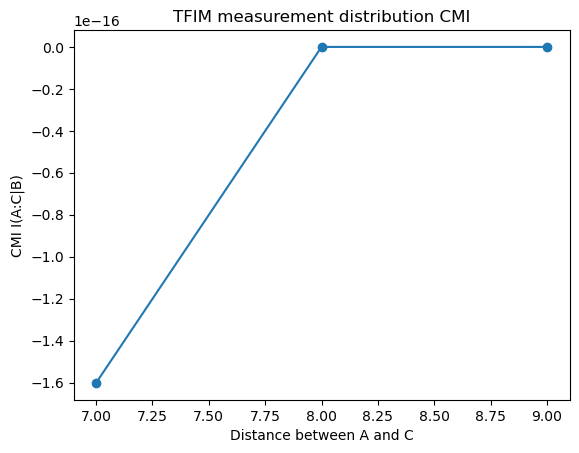

In [63]:
# apply TFIM to the CMI calculating model
import matplotlib.pyplot as plt

N = 10
H = tfim_hamiltonian(N, J=1000.0, h=1.0, periodic=False)
evals, evecs = eigh(H)
ground_state = evecs[:, 0]
dist = measurement_distribution(ground_state, N)

distances = []
cmis = []

for d in range(7, N): 
    A = [0]
    C = [d]
    B = list(range(1, d))
    cmi = conditional_mutual_information(dist, A, B, C)
    distances.append(d)
    cmis.append(cmi)

plt.plot(distances, cmis, marker='o')
plt.xlabel("Distance between A and C")
plt.ylabel("CMI I(A:C|B)")
plt.title("TFIM measurement distribution CMI")
plt.show()

In [64]:
# 让RNN学习chain probability而不是整个p(x1,...xn)
def sample_from_distribution(dist, n_samples):
    bitstrings = list(dist.keys())
    probs = np.array(list(dist.values()))# 把对应的概率拿出来变成数组
    probs = probs / probs.sum() #归一化

    idx = np.random.choice(len(bitstrings), size=n_samples, p=probs) # 抽n_samples次
    # 这里就是采样，按照p(x)这个分布
    samples = np.array([bitstrings[i] for i in idx], dtype=np.int64) 
    # 抽的是在bitstring里的序号，所以为了得到样本，还要对应回bitstring拿到这些bit
    return samples

samples = sample_from_distribution(dist, n_samples=5000)
print(samples.shape)  # (5000, N)

(5000, 10)


In [65]:
import numpy as np
import torch # 神经网络
import torch.nn as nn # 网络层
import torch.optim as optim # 优化器
import matplotlib.pyplot as plt

# ----------------------------
# RNN model
# ----------------------------
class TinyRNN(nn.Module):
    def __init__(self, hidden_size=32, embed_dim=8): # 每个bit映射成8维向量
        super().__init__() # PyTorch的标准写法
        self.embed = nn.Embedding(2, embed_dim)   # 0/1 -> vector
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_size, batch_first=True)
        # 可以加 num_layers = 2 到nn.RNN
        # 定义RNN层，输出h_t；batch_first指的是(batch,seq_len,feature)，先批量，再时间步
        self.out = nn.Linear(hidden_size, 2)      # logits for 0/1
        #### 把R^32映射为R^2？ 这里的z_t是logits，不是概率，softmax之后会变成概率
    def forward(self, x):
        # x shape: (batch, seq_len)
        e = self.embed(x)          # (batch, seq_len, embed_dim)
        h, _ = self.rnn(e)         # (batch, seq_len, hidden_size)
        logits = self.out(h)       # (batch, seq_len, 2)
        return logits
# 所以我们通过embedding扩维，是不是等于我们先爆炸式的增加熵，然后再通过学习的过程实现熵减。
# A: 是每个状态被表示成一个可学习的连续向量，like representation lifting
# 那最后我们得到的信息增加了还是减少了呢？可能是不变，而是信息被重新编码或更适合预测的形式
# can we try more hidden layers? yes

# ----------------------------
# Train RNN on bitstring samples
# ----------------------------
def train_rnn_on_samples(samples, epochs=1000, lr=1e-2, hidden_size=32, embed_dim=8):
    """
    samples: numpy array of shape (num_samples, N), entries are 0/1
    """

    x = torch.tensor(samples[:, :-1], dtype=torch.long)   # inputs: x1 ... x_{N-1}
    y = torch.tensor(samples[:, 1:], dtype=torch.long)    # targets: x2 ... x_N

    model = TinyRNN(hidden_size=hidden_size, embed_dim=embed_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss() # 这里面自带softmax

    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(x)   # shape: (batch, N-1, 2)

        # flatten time and batch dimensions together
        loss = criterion(logits.reshape(-1, 2), y.reshape(-1))

        loss.backward()
        optimizer.step() # 这一步theta参数被更新

        losses.append(loss.item())

        if epoch % 100 == 0 or epoch == epochs - 1:
            print(f"epoch {epoch:3d} | loss = {loss.item():.6f}")

    return model, losses


# ----------------------------
# Inspect learned conditional probabilities
# ----------------------------
def inspect_one_step_conditionals(model, prefix):
    """
    prefix: list like [0,1,1]
    model will output probabilities for the next bit after each position
    """
    model.eval()
    x = torch.tensor([prefix], dtype=torch.long)  # x shape (1, len(prefix))

    with torch.no_grad(): # 只是采样、预测，要关闭梯度计算
        logits = model(x)
        probs = torch.softmax(logits, dim=-1)     # shape (1, seq_len, 2)
        
    print(logits.shape)
    
    print(f"Input prefix = {prefix}")
    for t in range(len(prefix)):
        p0 = probs[0, t, 0].item()
        p1 = probs[0, t, 1].item()
        print(f" step {t}: p(next=0 | x_<={t})={p0:.4f}, p(next=1 | x_<={t})={p1:.4f}")

# ----------------------------
# Plot training curve
# ----------------------------
def plot_losses(losses, title="RNN training loss"):
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(title)
    plt.show()

epoch   0 | loss = 0.502920
epoch 100 | loss = 0.000102
epoch 200 | loss = 0.000063
epoch 300 | loss = 0.000041
epoch 400 | loss = 0.000029
epoch 500 | loss = 0.000022
epoch 600 | loss = 0.000017
epoch 700 | loss = 0.000014
epoch 800 | loss = 0.000011
epoch 900 | loss = 0.000009
epoch 999 | loss = 0.000008


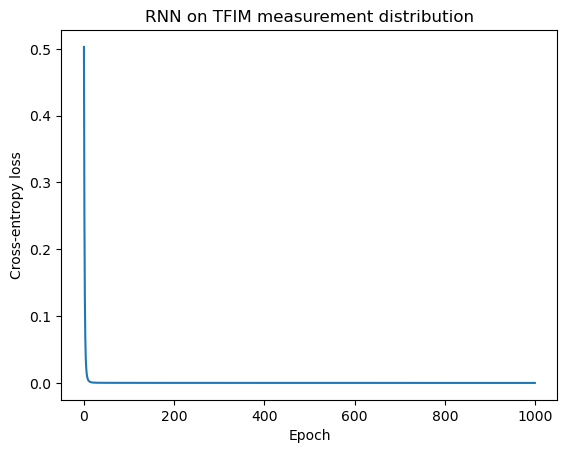

In [66]:
rnn_model, losses = train_rnn_on_samples(
    samples,
    epochs=1000,
    lr=1e-2,
    hidden_size=32,
    embed_dim=8
)

plot_losses(losses, title="RNN on TFIM measurement distribution")

In [67]:
inspect_one_step_conditionals(rnn_model, prefix=[1, 1, 0, 1, 1])

torch.Size([1, 5, 2])
Input prefix = [1, 1, 0, 1, 1]
 step 0: p(next=0 | x_<=0)=0.0000, p(next=1 | x_<=0)=1.0000
 step 1: p(next=0 | x_<=1)=0.0000, p(next=1 | x_<=1)=1.0000
 step 2: p(next=0 | x_<=2)=0.0000, p(next=1 | x_<=2)=1.0000
 step 3: p(next=0 | x_<=3)=0.0000, p(next=1 | x_<=3)=1.0000
 step 4: p(next=0 | x_<=4)=0.0000, p(next=1 | x_<=4)=1.0000


In [81]:
# 用RNN学出来的概率分布，算能量。
import numpy as np
import torch
from itertools import product

# ============================================
# 0. first-bit empirical distribution p(x1)
# ============================================
def estimate_p_x1(samples):
    """
    samples: numpy array of shape (num_samples, N), entries 0/1
    returns p_x1 where p_x1[0]=P(x1=0), p_x1[1]=P(x1=1)
    """
    p_x1 = np.bincount(samples[:, 0], minlength=2).astype(float)
    p_x1 /= p_x1.sum()
    return p_x1


# ============================================
# 1. probability of one bitstring from trained RNN
#    p_theta(x) = p(x1) * Π p_theta(x_i | x_<i)
# ============================================
def bitstring_prob(model, bitstring, p_x1):
    """
    bitstring: tuple/list like (0,1,1,0,...)
    p_x1: array-like shape (2,)
    """
    model.eval()
    bitstring = list(bitstring)
    N = len(bitstring)

    # first bit
    prob = float(p_x1[bitstring[0]])

    if N == 1:
        return prob

    # input to model: x1 ... x_{N-1}
    x_in = torch.tensor([bitstring[:-1]], dtype=torch.long)

    with torch.no_grad():
        logits = model(x_in)                     # shape (1, N-1, 2)
        probs = torch.softmax(logits, dim=-1)[0] # shape (N-1, 2)

    # probs[t] = p(x_{t+2} | x_1,...,x_{t+1})
    for t in range(N - 1):
        next_bit = bitstring[t + 1]
        prob *= probs[t, next_bit].item()

    return prob


# ============================================
# 2. full distribution from RNN (for small N)
# ============================================
def full_distribution_from_rnn(model, N, p_x1):
    dist = {}
    for bits in product([0, 1], repeat=N):
        dist[bits] = bitstring_prob(model, bits, p_x1)

    # normalize for numerical safety
    Z = sum(dist.values())
    for bits in dist:
        dist[bits] /= Z
    return dist


# ============================================
# 3. convert bitstring <-> spin
#    bit 0 -> +1, bit 1 -> -1
# ============================================
def bits_to_spins(bitstring):
    return np.array([1 - 2*b for b in bitstring], dtype=np.int64)


def flip_bit(bitstring, i): # 用来算翻转后配置的概率
    y = list(bitstring)
    y[i] = 1 - y[i]
    return tuple(y)


# ============================================
# 4. local energy for TFIM
#    H = -J Σ Z_i Z_{i+1} - h Σ X_i
# ============================================
def local_energy_tfim_from_prob(prob_fn, bitstring, J=1.0, h=100.0, periodic=False, eps=1e-15):
    """
    prob_fn(bits) should return p(bits)
    psi(bits) = sqrt(p(bits))
    """
    x = tuple(bitstring)
    N = len(x)

    p_x = max(prob_fn(x), eps)
    psi_x = np.sqrt(p_x)

    # diagonal ZZ part
    s = bits_to_spins(x)
    e_diag = 0.0
    for i in range(N - 1):
        e_diag += -J * s[i] * s[i + 1]
    if periodic:
        e_diag += -J * s[-1] * s[0]

    # off-diagonal X part
    e_off = 0.0
    for i in range(N):
        x_flip = flip_bit(x, i)
        p_flip = max(prob_fn(x_flip), eps)
        psi_flip = np.sqrt(p_flip)
        e_off += -h * (psi_flip / psi_x)

    return e_diag + e_off


# ============================================
# 5. exact total energy from a given distribution
#    E = Σ_x p(x) E_loc(x)
# ============================================
def exact_energy_from_distribution(dist, J=1.0, h=100.0, periodic=False):
    """
    dist: dict {bitstring: probability}
    """
    def prob_fn(bits):
        return dist[bits]

    E = 0.0
    for bits, p in dist.items():
        e_loc = local_energy_tfim_from_prob(
            prob_fn, bits, J=J, h=h, periodic=periodic
        )
        E += p * e_loc
    return E


# ============================================
# 6. compare RNN distribution vs exact distribution
# ============================================
def kl_divergence(p_dist, q_dist, eps=1e-15):
    """
    KL(P || Q) = Σ_x P(x) log[P(x)/Q(x)]
    """
    kl = 0.0
    for x, p in p_dist.items():
        p = max(p, eps)
        q = max(q_dist[x], eps)
        kl += p * np.log(p / q)
    return kl


def l1_distance(p_dist, q_dist):
    return sum(abs(p_dist[x] - q_dist[x]) for x in p_dist)


# ============================================
# 7. one-shot evaluation function
# ============================================
def evaluate_rnn_energy(model, samples, exact_dist, N, J=1000.0, h=1.0, periodic=False):
    """
    model      : trained RNN
    samples    : training samples used for fitting, shape (num_samples, N)
    exact_dist : exact measurement distribution from ED
    N          : number of spins
    """
    # first-bit prior from samples
    p_x1 = estimate_p_x1(samples)

    # distribution learned by RNN
    rnn_dist = full_distribution_from_rnn(model, N, p_x1)

    # energies
    E_exact = exact_energy_from_distribution(exact_dist, J=J, h=h, periodic=periodic)
    E_rnn   = exact_energy_from_distribution(rnn_dist,  J=J, h=h, periodic=periodic)

    # distance between distributions
    kl = kl_divergence(exact_dist, rnn_dist)
    l1 = l1_distance(exact_dist, rnn_dist)

    print("========== Comparison ==========")
    print(f"E_exact           = {E_exact:.10f}")
    print(f"E_from_RNN        = {E_rnn:.10f}")
    print(f"energy error      = {abs(E_rnn - E_exact):.10f}")
    print(f"KL(exact || rnn)  = {kl:.10f}")
    print(f"L1 distance       = {l1:.10f}")

    return {
        "p_x1": p_x1,
        "rnn_dist": rnn_dist,
        "E_exact": E_exact,
        "E_rnn": E_rnn,
        "energy_error": abs(E_rnn - E_exact),
        "KL_exact_rnn": kl,
        "L1": l1,
    }

In [82]:
# 把学好的RNN模型代入，求能量
results = evaluate_rnn_energy(
    model=rnn_model,
    samples=samples,     # 你训练RNN时用的 samples
    exact_dist=dist,     # 你前面 measurement_distribution(ground_state, N) 得到的 dist
    N=N,
    J=1000.0,
    h=1.0,             # 注意要保持一致
    periodic=False
)

========== Comparison ==========
E_exact           = -9000.0030000002
E_from_RNN        = -8999.7716940683
energy error      = 0.2313059319
KL(exact || rnn)  = 0.0000708494
L1 distance       = 0.0001382812


In [84]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

# =========================
# 1. TFIM parameters
# =========================
N = 10
J = 1000.0
h = 1.0

device = "cpu"


# =========================
# 2. Autoregressive RNN wavefunction
#    We model p_theta(s) over bits {0,1}
#    and define psi_theta(s) = sqrt(p_theta(s))
# =========================
class AR_RNN(nn.Module):
    def __init__(self, N, embed_dim=16, hidden_dim=32):
        super().__init__()
        self.N = N

        # tokens: 0, 1, BOS(=2)
        self.embed = nn.Embedding(3, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True) # rnn、GRU、LSTM
        self.out = nn.Linear(hidden_dim, 2)

    def logits_for_sequence(self, x):
        """
        x: (batch, N) with entries in {0,1}
        returns logits for each site:
            logits[:, i, :] = logits for x_i conditioned on x_<i
        """
        batch = x.shape[0]

        bos = torch.full((batch, 1), 2, dtype=torch.long, device=x.device)
        x_in = torch.cat([bos, x[:, :-1]], dim=1)   # teacher forcing input

        e = self.embed(x_in)                        # (batch, N, embed_dim)
        hseq, _ = self.rnn(e)                       # (batch, N, hidden_dim)
        logits = self.out(hseq)                     # (batch, N, 2)
        return logits

    def log_prob(self, x):
        """
        x: (batch, N) with entries in {0,1}
        returns log p_theta(x), shape (batch,)
        """
        logits = self.logits_for_sequence(x)  # (batch, N, 2)
        logp_all = F.log_softmax(logits, dim=-1)

        # pick the log-prob of the actually observed bit at each site
        logp_sites = logp_all.gather(2, x.unsqueeze(-1)).squeeze(-1)  # (batch, N)
        return logp_sites.sum(dim=1)

    def sample(self, batch_size):
        """
        direct autoregressive sampling from p_theta(x)
        returns:
            x_bits:   (batch, N) in {0,1}
            logp:     (batch,) log p_theta(x)
        """
        x = torch.zeros(batch_size, self.N, dtype=torch.long, device=device)
        logp_total = torch.zeros(batch_size, device=device)

        h = None
        token = torch.full((batch_size, 1), 2, dtype=torch.long, device=device)  # BOS

        for i in range(self.N):
            e = self.embed(token)                 # (batch, 1, embed_dim)
            out, h = self.rnn(e, h)               # out: (batch, 1, hidden_dim)
            logits = self.out(out[:, 0, :])       # (batch, 2)
            probs = torch.softmax(logits, dim=-1)

            sampled = torch.multinomial(probs, num_samples=1).squeeze(1)  # (batch,)
            x[:, i] = sampled

            logp_i = torch.log(probs[torch.arange(batch_size), sampled] + 1e-12)
            logp_total += logp_i

            token = sampled.unsqueeze(1)

        return x, logp_total


model = AR_RNN(N=N, embed_dim=16, hidden_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2)


# =========================
# 3. Convert between bit {0,1} and spin {-1,+1}
# =========================
def bits_to_spins(x_bits):
    # 0 -> -1, 1 -> +1
    return 2.0 * x_bits.float() - 1.0

def spins_to_bits(spins):
    # -1 -> 0, +1 -> 1
    return ((spins + 1.0) / 2.0).long()


# =========================
# 4. Diagonal part of TFIM in Z basis
#    H = -J sum Z_i Z_{i+1} - h sum X_i
# =========================
def diagonal_energy(spins, J=1.0):
    zz = spins[:, :-1] * spins[:, 1:]
    return -J * zz.sum(dim=1)


# =========================
# 5. log psi(s)
#    Since psi(s) = sqrt(p(s)), we have
#    log psi(s) = 0.5 * log p(s)
# =========================
def logpsi_from_spins(model, spins):
    x_bits = spins_to_bits(spins)
    logp = model.log_prob(x_bits)
    return 0.5 * logp


# =========================
# 6. Local energy
#    E_loc(s) = sum_s' H_{s,s'} psi(s') / psi(s)
# =========================
@torch.no_grad()
def local_energy(model, spins, J, h):
    batch = spins.shape[0]

    logpsi = logpsi_from_spins(model, spins)     # (batch,)
    e_diag = diagonal_energy(spins, J=J)         # (batch,)
    e_off = torch.zeros(batch, device=spins.device)

    for i in range(N):
        flipped = spins.clone()
        flipped[:, i] *= -1                      # apply X_i

        logpsi_flip = logpsi_from_spins(model, flipped)
        ratio = torch.exp(logpsi_flip - logpsi)  # psi(s^i)/psi(s)

        e_off += -h * ratio

    return e_diag + e_off


# =========================
# 7. Direct sampling from autoregressive model
#    Since x ~ p_theta(x) = |psi(x)|^2
# =========================
@torch.no_grad()
def sample_from_model(model, batch_size=256):
    x_bits, logp = model.sample(batch_size)
    spins = bits_to_spins(x_bits)
    return spins, logp


# =========================
# 8. One VMC training step
# =========================
def vmc_step(model, optimizer, batch_size=256, J=J, h=h):
    # direct autoregressive sampling
    spins, _ = sample_from_model(model, batch_size=batch_size)

    with torch.no_grad():
        e_loc = local_energy(model, spins, J=J, h=h)
        e_mean = e_loc.mean()

    logpsi = logpsi_from_spins(model, spins)

    # VMC surrogate loss:
    # grad loss = grad E
    loss = 2.0 * torch.mean((e_loc - e_mean).detach() * logpsi)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return e_mean.item(), e_loc.std().item()


# =========================
# 9. Train
# =========================
num_epochs = 30

for epoch in range(num_epochs):
    e_mean, e_std = vmc_step(model, optimizer, batch_size=256, J=J, h=h)

    if epoch % 2 == 0 or epoch == num_epochs - 1:
        print(f"epoch {epoch:3d} | energy = {e_mean:.6f} | std = {e_std:.6f}")

epoch   0 | energy = -103.735191 | std = 2810.088623
epoch   2 | energy = -3438.118408 | std = 3237.990723
epoch   4 | energy = -6591.080078 | std = 2279.570068
epoch   6 | energy = -7854.729980 | std = 1603.918579
epoch   8 | energy = -8291.163086 | std = 1136.206299
epoch  10 | energy = -8680.993164 | std = 794.443665
epoch  12 | energy = -8852.277344 | std = 524.395325
epoch  14 | energy = -8930.184570 | std = 368.099792
epoch  16 | energy = -8976.874023 | std = 214.794907
epoch  18 | energy = -8984.625000 | std = 175.414612
epoch  20 | energy = -9000.124023 | std = 0.000000
epoch  22 | energy = -8992.369141 | std = 123.705261
epoch  24 | energy = -8969.849609 | std = 293.302185
epoch  26 | energy = -8992.381836 | std = 123.034210
epoch  28 | energy = -8992.394531 | std = 122.686859
epoch  29 | energy = -9000.059570 | std = 0.000000


In [86]:
# Autoregressive RNN VMC for TFIM
# H = -J sum Z_i Z_{i+1} - h sum X_i

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

torch.manual_seed(0)
np.random.seed(0)

# =========================
# 1. Parameters
# =========================
N = 10
J = 1000.0
h = 1.0

device = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# 2. Autoregressive RNN wavefunction
#    p_theta(x) = Π_i p(x_i | x_<i)
#    psi_theta(x) = sqrt(p_theta(x))
#    log psi = 1/2 log p
# =========================
class AR_RNN(nn.Module):
    def __init__(self, N, embed_dim=16, hidden_dim=64, num_layers=1):
        super().__init__()
        self.N = N

        # tokens: 0, 1, BOS=2
        self.embed = nn.Embedding(3, embed_dim)

        self.rnn = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.out = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        """
        x: shape (batch, N), entries 0/1

        Return logits for:
        p(x_0 | BOS),
        p(x_1 | x_0),
        p(x_2 | x_0, x_1),
        ...
        """
        batch = x.shape[0]

        bos = torch.full(
            (batch, 1),
            2,
            dtype=torch.long,
            device=x.device
        )

        # input to RNN: BOS, x0, x1, ..., x_{N-2}
        x_in = torch.cat([bos, x[:, :-1]], dim=1)

        e = self.embed(x_in)        # (batch, N, embed_dim)
        h, _ = self.rnn(e)          # (batch, N, hidden_dim)
        logits = self.out(h)        # (batch, N, 2)

        return logits

    def log_prob(self, x):
        """
        Return log p_theta(x)
        """
        logits = self.forward(x)                  # (batch, N, 2)
        log_probs = F.log_softmax(logits, dim=-1)

        # pick log p(x_i | x_<i) at the actual bit x_i
        chosen = log_probs.gather(
            dim=2,
            index=x.unsqueeze(-1)
        ).squeeze(-1)                              # (batch, N)

        return chosen.sum(dim=1)                  # (batch,)

    def log_psi(self, x):
        """
        psi(x) = sqrt(p(x))
        therefore log psi(x) = 1/2 log p(x)
        """
        return 0.5 * self.log_prob(x)

    @torch.no_grad()
    def sample(self, batch_size):
        """
        Direct autoregressive sampling.
        No Metropolis needed.
        """
        samples = []

        prev_token = torch.full(
            (batch_size, 1),
            2,                      # BOS
            dtype=torch.long,
            device=device
        )

        hidden = None

        for _ in range(self.N):
            e = self.embed(prev_token)             # (batch, 1, embed_dim)
            out, hidden = self.rnn(e, hidden)      # out: (batch, 1, hidden_dim)

            logits = self.out(out[:, -1, :])       # (batch, 2)
            probs = torch.softmax(logits, dim=-1)  # (batch, 2)

            next_bit = torch.multinomial(probs, num_samples=1)  # (batch, 1)

            samples.append(next_bit)
            prev_token = next_bit

        return torch.cat(samples, dim=1)           # (batch, N)


# =========================
# 3. Diagonal TFIM energy
#    bit 0 -> spin +1
#    bit 1 -> spin -1
# =========================
def bits_to_spins(x):
    return 1.0 - 2.0 * x.float()


def diagonal_energy(x, J=1.0, periodic=False):
    """
    x: shape (batch, N), entries 0/1
    """
    spins = bits_to_spins(x)

    zz = spins[:, :-1] * spins[:, 1:]
    e_diag = -J * zz.sum(dim=1)

    if periodic:
        e_diag += -J * spins[:, -1] * spins[:, 0]

    return e_diag


# =========================
# 4. Local energy
#
# E_loc(x) = (H psi)(x) / psi(x)
#
# For TFIM:
# diagonal part:
#   -J sum s_i s_{i+1}
#
# off-diagonal X part:
#   -h sum_i psi(x flipped at i) / psi(x)
# =========================
@torch.no_grad()
def local_energy(model, x, J=1.0, h=1.0, periodic=False):
    """
    x: shape (batch, N), entries 0/1
    """
    batch, N = x.shape

    logpsi_x = model.log_psi(x)              # (batch,)
    e_diag = diagonal_energy(x, J=J, periodic=periodic)

    # construct all single-spin-flipped configurations
    x_flip = x.unsqueeze(1).repeat(1, N, 1)  # (batch, N, N)

    idx = torch.arange(N, device=x.device)
    x_flip[:, idx, idx] = 1 - x_flip[:, idx, idx]

    x_flip_flat = x_flip.reshape(batch * N, N)

    logpsi_flip = model.log_psi(x_flip_flat)
    logpsi_flip = logpsi_flip.reshape(batch, N)

    ratio = torch.exp(logpsi_flip - logpsi_x[:, None])

    e_off = -h * ratio.sum(dim=1)

    return e_diag + e_off


# =========================
# 5. One VMC step
#
# grad E = 2 <(E_loc - E_mean) grad log psi>
#
# The loss below is a surrogate loss.
# Its value is not the physical energy,
# but its gradient gives the VMC update.
# =========================
def vmc_step(model, optimizer, batch_size=512, J=1.0, h=1.0, periodic=False):
    # sample x ~ |psi|^2 = p_theta(x)
    with torch.no_grad():
        x = model.sample(batch_size)
        e_loc = local_energy(model, x, J=J, h=h, periodic=periodic)
        e_mean = e_loc.mean()
        e_std = e_loc.std()

    # recompute log psi with gradient
    logpsi = model.log_psi(x)

    loss = 2.0 * torch.mean((e_loc - e_mean) * logpsi)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return e_mean.item(), e_std.item(), loss.item()


# =========================
# 6. Train
# =========================
model = AR_RNN(N=N, embed_dim=16, hidden_dim=64, num_layers=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

energies = []
stds = []

num_epochs = 500
batch_size = 512

for epoch in range(num_epochs):
    e_mean, e_std, loss_value = vmc_step(
        model,
        optimizer,
        batch_size=batch_size,
        J=J,
        h=h,
        periodic=False
    )

    energies.append(e_mean)
    stds.append(e_std)

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(
            f"epoch {epoch:4d} | "
            f"E = {e_mean:.6f} | "
            f"E/site = {e_mean / N:.6f} | "
            f"std = {e_std:.6f}"
        )

epoch    0 | E = -545.087585 | E/site = -54.508759 | std = 2988.795654
epoch   20 | E = -6680.565430 | E/site = -668.056543 | std = 2079.325928
epoch   40 | E = -8162.251465 | E/site = -816.225146 | std = 1167.590088
epoch   60 | E = -8532.514648 | E/site = -853.251465 | std = 874.123962
epoch   80 | E = -8747.098633 | E/site = -874.709863 | std = 741.963196
epoch  100 | E = -8887.668945 | E/site = -888.766895 | std = 507.197144
epoch  120 | E = -8930.147461 | E/site = -893.014746 | std = 367.779968
epoch  140 | E = -8949.886719 | E/site = -894.988672 | std = 334.648071
epoch  160 | E = -8980.743164 | E/site = -898.074316 | std = 196.157486
epoch  180 | E = -8980.729492 | E/site = -898.072949 | std = 196.056213
epoch  200 | E = -8965.168945 | E/site = -896.516895 | std = 261.870941
epoch  220 | E = -8976.830078 | E/site = -897.683008 | std = 214.346100
epoch  240 | E = -8981.126953 | E/site = -898.112695 | std = 224.959320
epoch  260 | E = -8957.900391 | E/site = -895.790039 | std = 33